In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset , DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [34]:
# set random seed for reproducibility
torch.manual_seed(42)

In [35]:
import kagglehub
# Download dataset
path = kagglehub.dataset_download("zalando-research/fashionmnist")

train_path = "/kaggle/input/fashionmnist/fashion-mnist_train.csv"
df = pd.read_csv(train_path)

Using Colab cache for faster access to the 'fashionmnist' dataset.


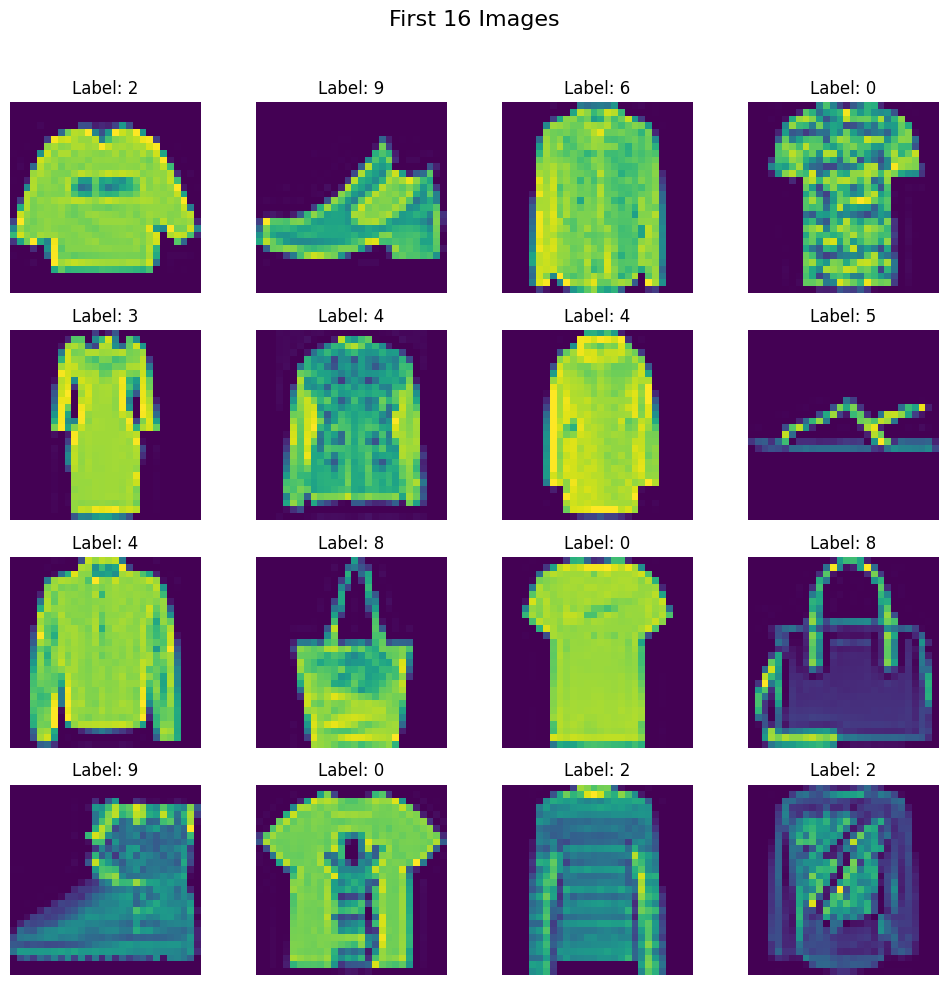

In [36]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [37]:
X = df.drop('label', axis=1)
y = df['label']

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
# scaling the features
X_train = X_train/255.0
X_test = X_test/255.0

In [40]:
# create custom Datset class
class CustomDataset(Dataset):

  def __init__(self,features,labels):
    self.features = torch.tensor(features.values,dtype = torch.float32)
    self.labels = torch.tensor(labels.values,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

In [41]:
# create object of train and test dataset
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [42]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [43]:
class ANN(nn.Module):

  def __init__(self,input_dim,output_dim,num_of_hidden_layers,neurons_per_layer,dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_of_hidden_layers):

      layers.append(nn.Linear(input_dim,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer,output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)

In [44]:
# objective function
def objective(trial):

  # next hyperparameter values from search space
  num_of_hidden_layers = trial.suggest_int('num_of_hidden_layer',1,5)
  neurons_per_layer = trial.suggest_int('neurons_per_layer',8,128,step=8)
  learning_rate = trial.suggest_float('learning_rate',1e-5,1e-1,log=True)
  epochs = trial.suggest_int('epochs',10,50,step = 10)
  dropout_rate = trial.suggest_float('dropout_rate',0.1,0.5,step=0.1)
  batch_size = trial.suggest_categorical('batch_size',[32,64,128])
  optimizer_name = trial.suggest_categorical('optimizer',['Adam','sgd','RMSprop'])
  weight_decay = trial.suggest_float('weight_decay',1e-5,1e-1,log=True)

  # create object of data loader of train and test
  train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,pin_memory=True)
  test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False,pin_memory=True)

  # initialize the model
  input_dim = 784
  output_dim = 10

  model = ANN(input_dim,output_dim,num_of_hidden_layers,neurons_per_layer,dropout_rate)
  model.to(device)


# optimizer selection
  criterion = nn.CrossEntropyLoss()

  if optimizer_name == 'Adam':
    optimizer = optim.Adam(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
  elif optimizer_name == 'sgd':
    optimizer = optim.SGD(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
  else:
    optimizer = optim.RMSprop(model.parameters(),lr=learning_rate,weight_decay=weight_decay)



  # training loop

  for epoch in range(epochs):

    for batch_features,batch_labels in train_loader:

        # move to gpu
        batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

        # forward pass
        predications = model(batch_features)

        # calculate loss
        loss = criterion(predications,batch_labels)

        # make grad zero
        optimizer.zero_grad()

        # backward pass
        loss.backward()

        # update parameter
        optimizer.step()

  # evaluation
  model.eval()

  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in test_loader:

      batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

      outputs = model(batch_features)

      _, predicted = torch.max(outputs, 1)

      total = total + batch_labels.shape[0]

      correct = correct + (predicted == batch_labels).sum().item()

  accuracy = correct/total

  return accuracy

In [45]:
!pip install optuna

In [46]:
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=10)

[I 2026-06-09 11:02:25,175] A new study created in memory with name: no-name-ff8ab3e3-3351-4260-8d30-800d3911376c
[I 2026-06-09 11:03:38,110] Trial 0 finished with value: 0.8680833333333333 and parameters: {'num_of_hidden_layer': 4, 'neurons_per_layer': 48, 'learning_rate': 2.544618330378046e-05, 'epochs': 20, 'dropout_rate': 0.1, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.00031308990904817214}. Best is trial 0 with value: 0.8680833333333333.
[I 2026-06-09 11:07:07,300] Trial 1 finished with value: 0.7601666666666667 and parameters: {'num_of_hidden_layer': 4, 'neurons_per_layer': 104, 'learning_rate': 3.575087310103177e-05, 'epochs': 40, 'dropout_rate': 0.2, 'batch_size': 32, 'optimizer': 'sgd', 'weight_decay': 1.785772555743189e-05}. Best is trial 0 with value: 0.8680833333333333.
[I 2026-06-09 11:08:01,907] Trial 2 finished with value: 0.81025 and parameters: {'num_of_hidden_layer': 2, 'neurons_per_layer': 64, 'learning_rate': 0.012690368164434241, 'epochs': 30, 'dropou

In [47]:
study.best_value

0.891

In [48]:
study.best_params

{'num_of_hidden_layer': 4,
 'neurons_per_layer': 128,
 'learning_rate': 3.582145206023572e-05,
 'epochs': 40,
 'dropout_rate': 0.2,
 'batch_size': 128,
 'optimizer': 'Adam',
 'weight_decay': 0.016019068997539056}